# Reproducing Bayesian DRO experiment

We ran the script given to use by the authors. We made the following changes to the script:

- For each replication, we run functions `main_Bayesian_DRO` and `main_empirical_DRO_Wasserstein` in parallel using the [joblib Parallel](https://joblib.readthedocs.io/en/latest/generated/joblib.Parallel.html) class.
- We did not run `main_DRO`, `main_empirical`, `main_Bayesian_DRO_epsilon1`, `main_Bayesian_DRO_epsilon2`, `main_Bayesian_DRO_epsilon3`.
- For each replication, we save a CSV file containing the solution and cost for each epsilon via a pandas dataframe. Each replication file is called `result_k.csv`, where `k` is the replication number.

You can see the exact differences between the files by running the `diff` command, the output of which looks like:


## Analysing results

In the following notebook, we concatenate all the CSV files together, then group by epsilon.
For each epsilon group, we calculate the out-of-sample mean and variance of the objective function $G(x, \xi)$.
We also calculate the mean and variance solution variable $x$. 



In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bayesian_dro.Bayesian_DRO_continuous import cost, data_generation, EPSILON_SET

In [36]:
experiment_dir = Path("/dcs/large/u1508153/misdro/og2")
assert experiment_dir.exists()
replication = 200
results_df = pd.concat([pd.read_csv(experiment_dir / f"result_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon"]).drop("Unnamed: 0", axis="columns")
results_df

wasserstein_dro_sol  wasserstein_dro_cost  \
replication epsilon                                              
0           0.001              17.901393             19.432516   
            0.002              17.901537             19.431938   
            0.005              17.901970             19.430206   
            0.010              17.902692             19.427320   
            0.020              17.904135             19.421546   
...                                  ...                   ...   
199         1.000              20.197447              5.340740   
            1.500              20.269615              5.557246   
            2.000              20.341784              5.773753   
            2.500              20.413953              5.990259   
            3.000              20.486122              6.206765   

                     bayesian_dro_sol  bayesian_dro_cost  
replication epsilon                                       
0           0.001               14.14          34.478086  
            0.002               14.32          33.758086  
            0.005               14.68          32.318086  
            0.010               15.02          30.958086  
            0.020               15.51          28.998086  
...                               ...                ...  
199         1.000               29.28          32.588400  
            1.500               29.96          34.628400  
            2.000               33.08          43.988400  
            2.500               45.45          81.098400  
            3.000               47.53          87.338400  

[3600 rows x 4 columns]

In [37]:
# data_eval = data_generation(replication)
# test_samples = np.repeat(data_eval, len(EPSILON_SET))
# results_df["bayesian_dro_cost"] = cost(results_df["bayesian_dro_sol"], test_samples)
# results_df["bayesian_dro_lse_cost"] = cost(results_df["bayesian_dro_lse_sol"], test_samples)
# results_df[["bayesian_dro_sol", "bayesian_dro_lse_sol", "bayesian_dro_cost", "bayesian_dro_lse_cost"]]


In [38]:
# np.sum(np.isclose(results_df["bayesian_dro_cost"], results_df["bayesian_dro_lse_cost"]))

In [39]:
gb = results_df.groupby(by="epsilon")
mean_df = gb.mean()
var_df = gb.var()
var_df

,wasserstein_dro_sol,wasserstein_dro_cost,bayesian_dro_sol,bayesian_dro_cost
epsilon,,,,
0.001,4.703799,97.025159,2.254060,185.852567
0.002,4.703799,97.023696,2.300175,181.684470
0.005,4.703799,97.019309,2.480422,173.930742
0.010,4.703799,97.012007,2.573015,165.465110
0.020,4.703799,96.997442,3.074735,154.105235
0.050,4.703799,96.954055,3.215320,130.006585
0.100,4.703799,96.882768,3.602734,105.379912
0.150,4.703799,96.812763,4.447751,96.890376
0.200,4.703799,96.744039,4.663682,94.621940


In [40]:
epsilon = 2.0
cost_values = results_df.loc[results_df.index.get_level_values("epsilon") == epsilon]["bayesian_dro_cost"]
mu = np.mean(cost_values)
var = 1.0/(len(cost_values) -1) * np.sum((cost_values - mu)**2)
np.isclose(var_df.at[epsilon, "bayesian_dro_cost"], var)

True

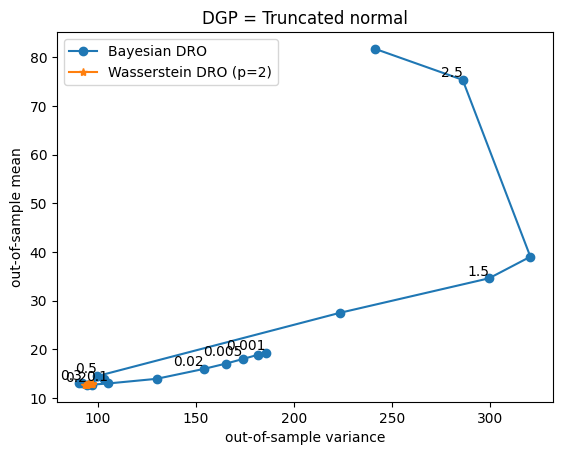

In [43]:
plt.plot(var_df["bayesian_dro_cost"], mean_df["bayesian_dro_cost"], marker='o', label="Bayesian DRO")
plt.plot(var_df["wasserstein_dro_cost"], mean_df["wasserstein_dro_cost"], marker='*', label="Wasserstein DRO (p=2)")
# plt.plot(var_df["bayesian_dro_lse_cost"], mean_df["bayesian_dro_lse_cost"], marker='x', label="BDRO LSE")

plt.title(f"DGP = Truncated normal")
plt.legend()
plt.xlabel("out-of-sample variance")
plt.ylabel("out-of-sample mean")

for i, label in enumerate(mean_df.index.values):
    if i % 2 == 0:
        # plt.text(var_df["wasserstein_dro_cost"].iloc[i], mean_df["wasserstein_dro_cost"].iloc[i], label, ha='right', va='bottom')
        plt.text(var_df["bayesian_dro_cost"].iloc[i], mean_df["bayesian_dro_cost"].iloc[i], label, ha='right', va='bottom')

In [19]:
mean_df[["bayesian_dro_sol"]]

,bayesian_dro_sol
epsilon,
0.001,15.72815
0.002,15.89490
0.005,16.20675
0.010,16.58220
0.020,17.13600
0.050,18.17820
0.100,19.20045
0.150,19.98925
0.200,20.49495


In [20]:
var_df[["bayesian_dro_sol"]]

,bayesian_dro_sol
epsilon,
0.001,2.254060
0.002,2.300175
0.005,2.480422
0.010,2.573015
0.020,3.074735
0.050,3.215320
0.100,3.602734
0.150,4.447751
0.200,4.663682
